# ESRB Video Game Rating 
### From Raw Data to a Tuned Classification Model

---

**Dataset:** `Video_games_esrb_rating.csv`  
**Goal:** Predict a game's ESRB rating (E, ET, T, M) from its content descriptors  
**Pipeline:** Data Understanding > EDA > Insights > Cleaning > Outlier Treatment > Feature Engineering > Feature Selection > Modeling > Tuning > Final Results > Conclusion


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 100,
                     'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52']
print('All libraries loaded.')

All libraries loaded.


---
# SECTION 1 — DATA UNDERSTANDING
> Before any analysis, understand the structure, types, size, and quality of the data.


### 1.1 Load the Dataset

In [4]:
df = pd.read_csv('dataset/Video_games_esrb_rating.csv')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Rows    : 1,895
Columns : 34


### 1.2 Column Names & Data Types

In [5]:
pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Sample': [df[c].iloc[0] for c in df.columns]
})

,Column,Dtype,Sample
0,title,str,Monster Jam Steel Titans 2
1,console,int64,1
2,alcohol_reference,int64,0
3,animated_blood,int64,0
4,blood,int64,0
5,blood_and_gore,int64,0
6,cartoon_violence,int64,0
7,crude_humor,int64,0
8,drug_reference,int64,0
9,fantasy_violence,int64,0


**Interpretation:**
- `title` — game name (string identifier, not a feature)
- `console` — binary (0/1), likely single vs multi-platform
- Columns 3-33 — binary content descriptor flags (0 = absent, 1 = present)
- `esrb_rating` — target label: E / ET / T / M


### 1.3 Sample Data

In [6]:
df.head(10)

,title,console,alcohol_reference,animated_blood,blood,blood_and_gore,cartoon_violence,crude_humor,drug_reference,fantasy_violence,...,sexual_content,sexual_themes,simulated_gambling,strong_janguage,strong_sexual_content,suggestive_themes,use_of_alcohol,use_of_drugs_and_alcohol,violence,esrb_rating
0,Monster Jam Steel Titans 2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
1,Subnautica: Below Zero,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ET
2,NIER REPLICANT VER.1.22474487139…,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,M
3,Jamestown+,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,ET
4,Neptunia Virtual Stars,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,T
5,Monster Energy Supercross - The Official Video...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
6,Monochrome Order,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,T
7,Blightbound,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,T
8,Maquette,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ET
9,FATAL FURY™ BATTLE ARCHIVES VOL.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,T


### 1.4 Summary Statistics

In [7]:
binary_cols = [c for c in df.columns if c not in ['title', 'esrb_rating']]
df[binary_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
console,1895.0,0.475,0.500,0.0,0.0,0.0,1.0,1.0
alcohol_reference,1895.0,0.050,0.218,0.0,0.0,0.0,0.0,1.0
animated_blood,1895.0,0.010,0.100,0.0,0.0,0.0,0.0,1.0
blood,1895.0,0.228,0.420,0.0,0.0,0.0,0.0,1.0
blood_and_gore,1895.0,0.126,0.332,0.0,0.0,0.0,0.0,1.0
cartoon_violence,1895.0,0.020,0.138,0.0,0.0,0.0,0.0,1.0
crude_humor,1895.0,0.054,0.227,0.0,0.0,0.0,0.0,1.0
drug_reference,1895.0,0.035,0.183,0.0,0.0,0.0,0.0,1.0
fantasy_violence,1895.0,0.221,0.415,0.0,0.0,0.0,0.0,1.0
intense_violence,1895.0,0.118,0.323,0.0,0.0,0.0,0.0,1.0


### 1.5 Target Variable Distribution

In [8]:
rating_counts = df['esrb_rating'].value_counts()
print('ESRB Rating Counts:')
print(rating_counts)
print(f'\nClass balance ratio (max/min): {rating_counts.max()/rating_counts.min():.2f}x')
print(f'\nProportions:')
print((rating_counts / len(df)).round(3))

ESRB Rating Counts:
esrb_rating
T     689
E     416
ET    403
M     387
Name: count, dtype: int64

Class balance ratio (max/min): 1.78x

Proportions:
esrb_rating
T     0.364
E     0.220
ET    0.213
M     0.204
Name: count, dtype: float64


### 1.6 Missing Values & Duplicates

In [9]:
missing = df.isnull().sum()
print('=== MISSING VALUES ===')
if missing.any():
    print(missing[missing > 0])
else:
    print('No missing values found.')
print(f'\n=== DUPLICATES ===')
print(f'Full duplicate rows : {df.duplicated().sum()}')
print(f'Duplicate titles    : {df.duplicated(subset="title").sum()}')

=== MISSING VALUES ===
No missing values found.

=== DUPLICATES ===
Full duplicate rows : 0
Duplicate titles    : 0


---
# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)
> EDA lets us see patterns, distributions, and relationships before making assumptions.


### 2.1 Univariate — Target Distribution

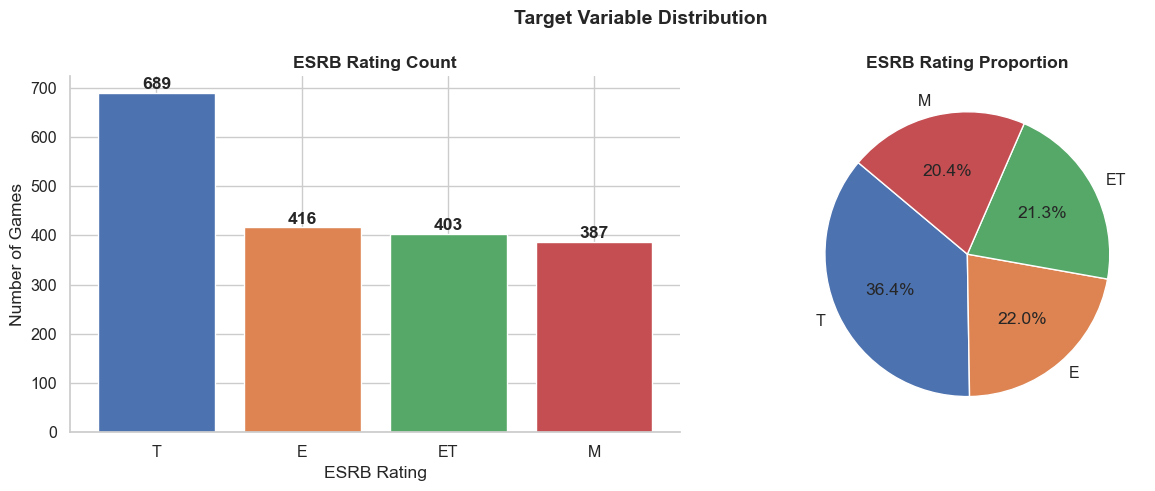

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rating_counts = df['esrb_rating'].value_counts()

axes[0].bar(rating_counts.index, rating_counts.values, color=PALETTE, edgecolor='white')
for i, (lbl, cnt) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(i, cnt + 8, str(cnt), ha='center', fontweight='bold')
axes[0].set_title('ESRB Rating Count', fontweight='bold')
axes[0].set_xlabel('ESRB Rating')
axes[0].set_ylabel('Number of Games')

axes[1].pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('ESRB Rating Proportion', fontweight='bold')
plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**What this tells us:**  
T (Teen) dominates at ~36%. M (Mature) is the smallest at ~20%.  
The imbalance ratio is ~1.78x — enough to make accuracy misleading.  
A model always predicting 'T' would score 36% without learning anything.  
**We use F1 Macro as our primary metric.**


### 2.2 Univariate — Content Descriptor Frequency

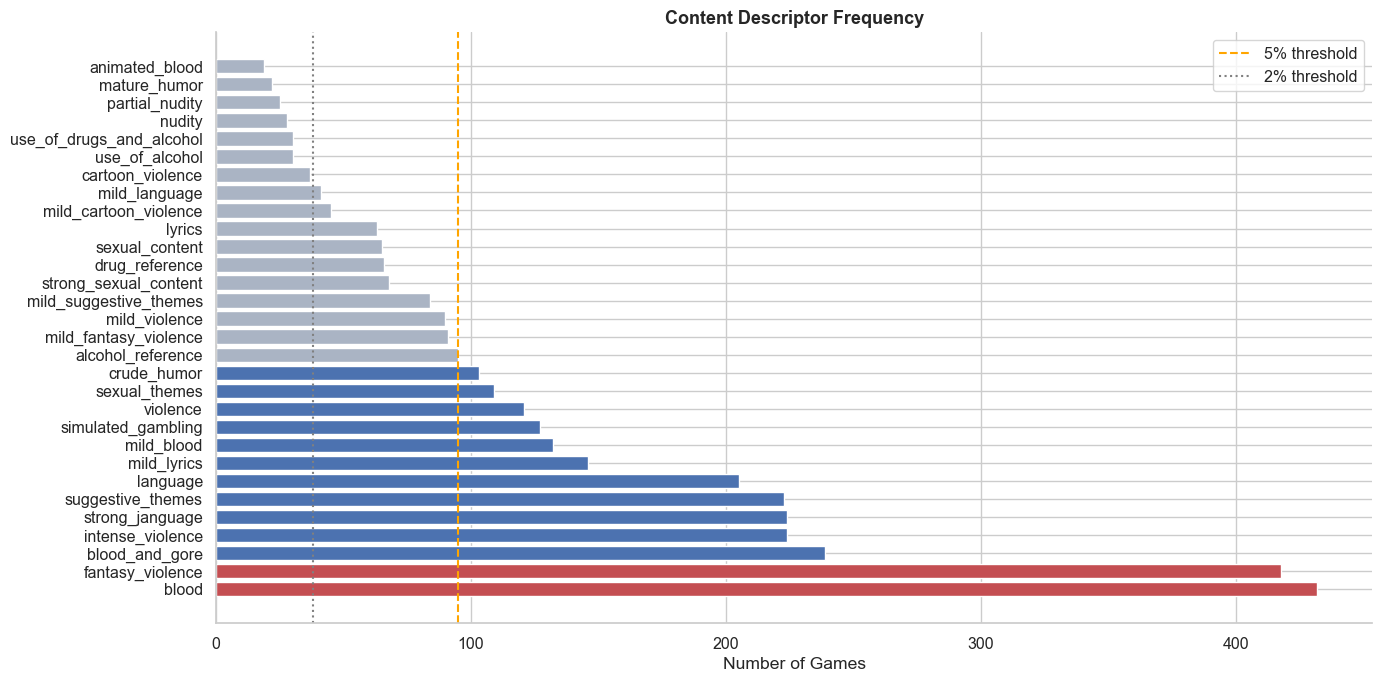

Top 5 most common:
blood               432
fantasy_violence    418
blood_and_gore      239
intense_violence    224
strong_janguage     224

Bottom 5 rarest:
use_of_drugs_and_alcohol    30
nudity                      28
partial_nudity              25
mature_humor                22
animated_blood              19


In [11]:
desc_cols = [c for c in df.columns if c not in ['title','console','no_descriptors','esrb_rating']]
desc_freq = df[desc_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#C44E52' if v > 300 else '#4C72B0' if v > 100 else '#aab4c4' for v in desc_freq.values]
ax.barh(desc_freq.index, desc_freq.values, color=colors, edgecolor='white')
ax.axvline(len(df)*0.05, color='orange', linestyle='--', label='5% threshold')
ax.axvline(len(df)*0.02, color='gray', linestyle=':', label='2% threshold')
ax.set_xlabel('Number of Games')
ax.set_title('Content Descriptor Frequency', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 most common:')
print(desc_freq.head(5).to_string())
print('\nBottom 5 rarest:')
print(desc_freq.tail(5).to_string())

**What this tells us:**  
cartoon_violence, fantasy_violence, and violence appear most frequently.  
14 descriptors appear in fewer than 2% of games — too sparse to be useful individually.  
These will be consolidated into a single `rare_content` flag.


### 2.3 Univariate — Descriptor Count per Game

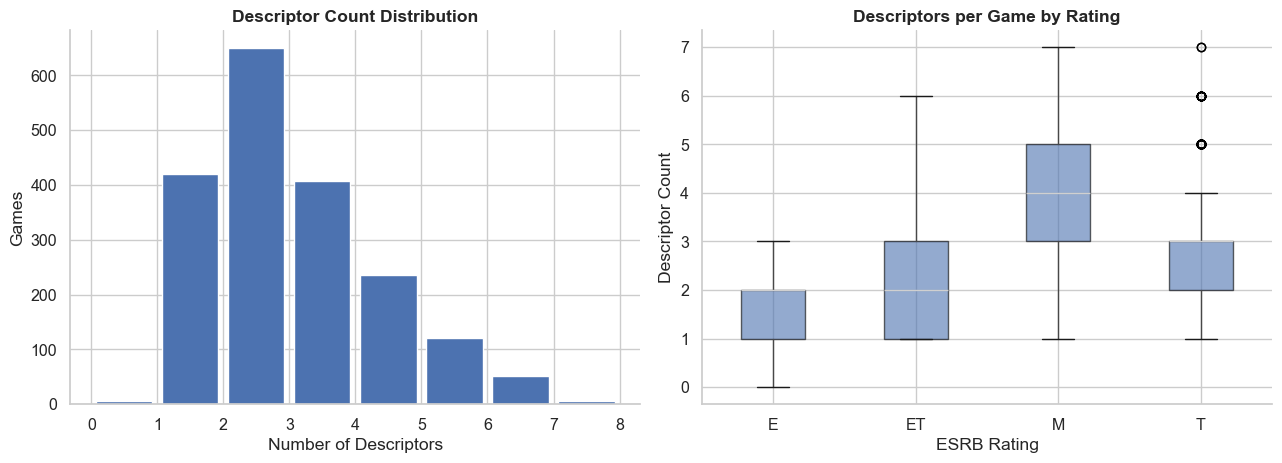

             count  mean   std  min  25%  50%  75%  max
esrb_rating                                            
E            416.0  1.56  0.56  0.0  1.0  2.0  2.0  3.0
ET           403.0  2.20  1.08  1.0  1.0  2.0  3.0  6.0
M            387.0  3.58  1.36  1.0  3.0  4.0  5.0  7.0
T            689.0  2.76  1.22  1.0  2.0  3.0  3.0  7.0


In [12]:
all_desc = [c for c in df.columns if c not in ['title','esrb_rating']]
df['_desc_count'] = df[all_desc].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['_desc_count'], bins=range(0, df['_desc_count'].max()+2),
             color='#4C72B0', edgecolor='white', rwidth=0.85)
axes[0].set_title('Descriptor Count Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Descriptors')
axes[0].set_ylabel('Games')

df.boxplot(column='_desc_count', by='esrb_rating', ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[1].set_title('Descriptors per Game by Rating', fontweight='bold')
axes[1].set_xlabel('ESRB Rating')
axes[1].set_ylabel('Descriptor Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('esrb_rating')['_desc_count'].describe().round(2))

**What this tells us:**  
M-rated games average far more descriptors than E-rated games.  
Descriptor count alone is already a strong predictor of rating.  
This justifies creating a `descriptor_count` engineered feature.


### 2.4 Bivariate — Descriptor Presence by Rating (Heatmap)

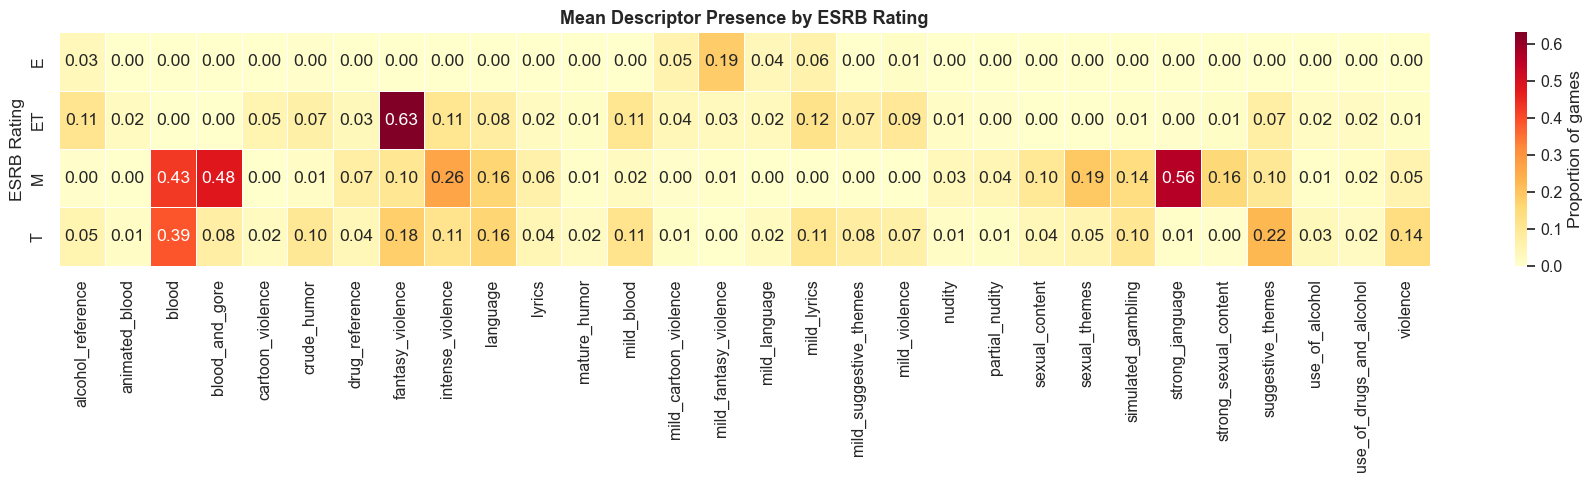

In [13]:
desc_by_rating = df.groupby('esrb_rating')[desc_cols].mean()

plt.figure(figsize=(18, 5))
sns.heatmap(desc_by_rating, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.4, cbar_kws={'label': 'Proportion of games'})
plt.title('Mean Descriptor Presence by ESRB Rating', fontweight='bold', fontsize=13)
plt.ylabel('ESRB Rating')
plt.tight_layout()
plt.show()

**What this tells us:**  
- E : cartoon_violence, fantasy_violence, no_descriptors
- ET: mild_cartoon_violence, mild_fantasy_violence
- T : violence, language, suggestive_themes
- M : intense_violence, blood_and_gore, strong_language

This heatmap is essentially a visual decision tree for ESRB ratings.


### 2.5 Bivariate — Top 12 Descriptors by Rating

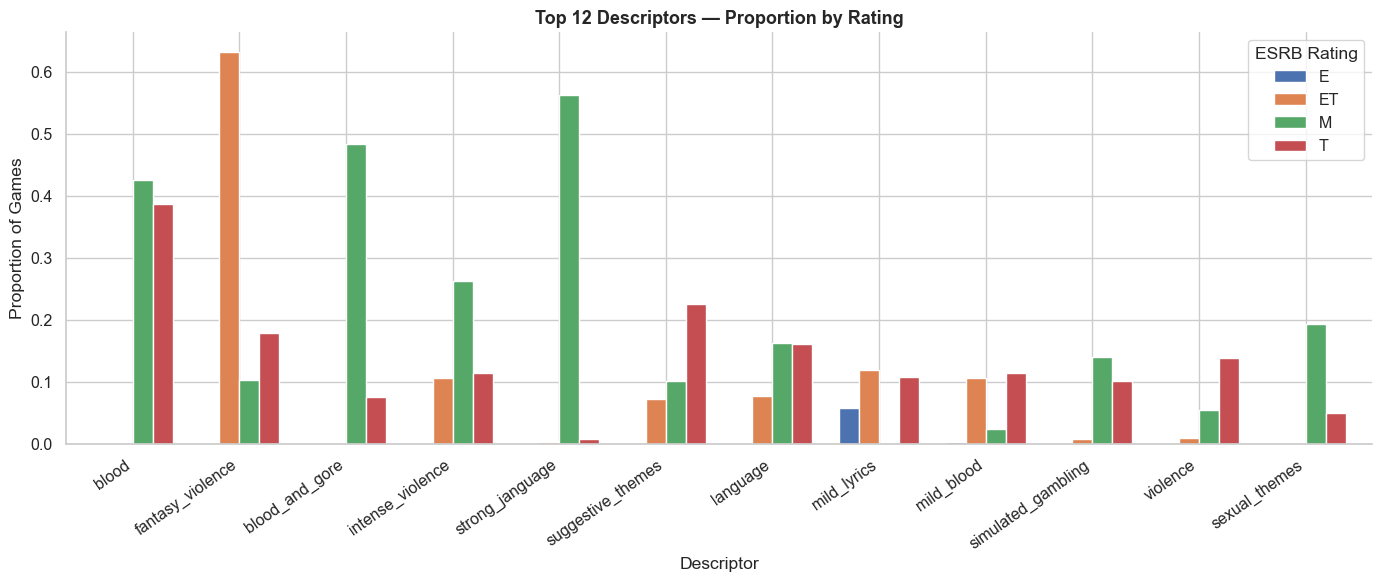

In [14]:
top12 = desc_freq.head(12).index.tolist()
df.groupby('esrb_rating')[top12].mean().T.plot(
    kind='bar', figsize=(14, 6), color=PALETTE, edgecolor='white', width=0.75)
plt.title('Top 12 Descriptors — Proportion by Rating', fontweight='bold', fontsize=13)
plt.xlabel('Descriptor')
plt.ylabel('Proportion of Games')
plt.xticks(rotation=35, ha='right')
plt.legend(title='ESRB Rating')
plt.tight_layout()
plt.show()

### 2.6 Correlation — Descriptors vs Target

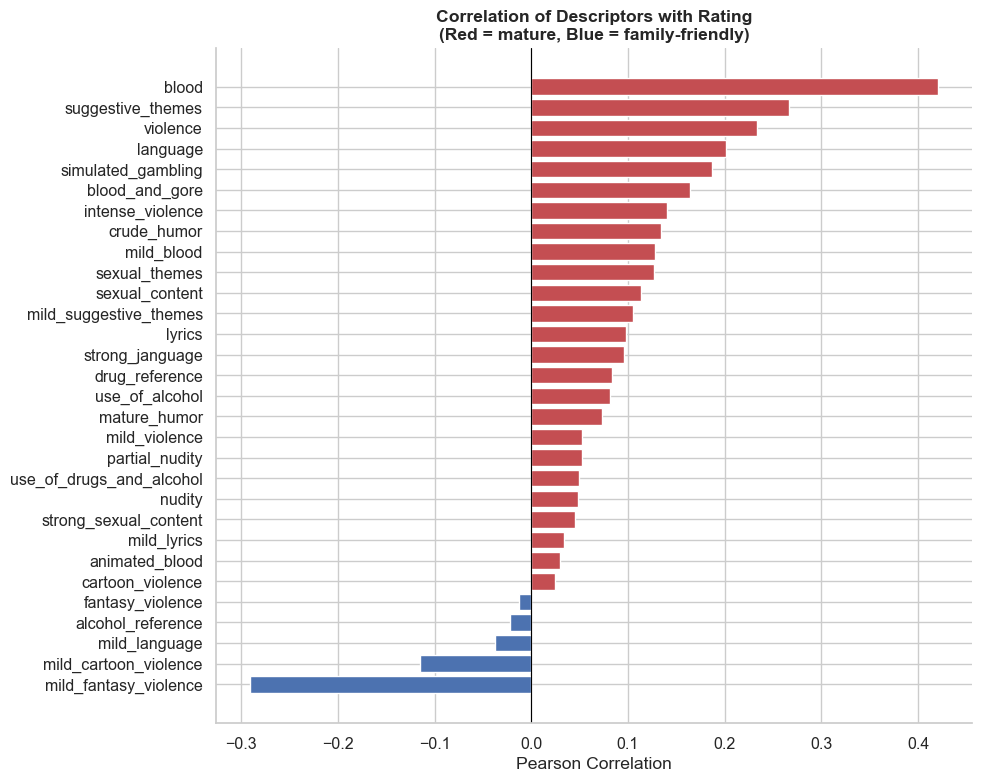

Strongest mature correlators:
simulated_gambling    0.187
language              0.202
violence              0.234
suggestive_themes     0.266
blood                 0.420
Name: _rating_enc, dtype: float64

Strongest family-friendly correlators:
mild_fantasy_violence   -0.290
mild_cartoon_violence   -0.116
mild_language           -0.038
alcohol_reference       -0.022
fantasy_violence        -0.013
Name: _rating_enc, dtype: float64


In [15]:
le_tmp = LabelEncoder()
df['_rating_enc'] = le_tmp.fit_transform(df['esrb_rating'])

corr_target = (df[desc_cols + ['_rating_enc']]
               .corr()['_rating_enc'].drop('_rating_enc').sort_values())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Descriptors with Rating\n(Red = mature, Blue = family-friendly)',
             fontweight='bold')
ax.set_xlabel('Person Correlation')
plt.tight_layout()
plt.show()

print('Strongest mature correlators:')
print(corr_target.tail(5).round(3))
print('\nStrongest family-friendly correlators:')
print(corr_target.head(5).round(3))

### 2.7 Inter-Descriptor Correlation Heatmap

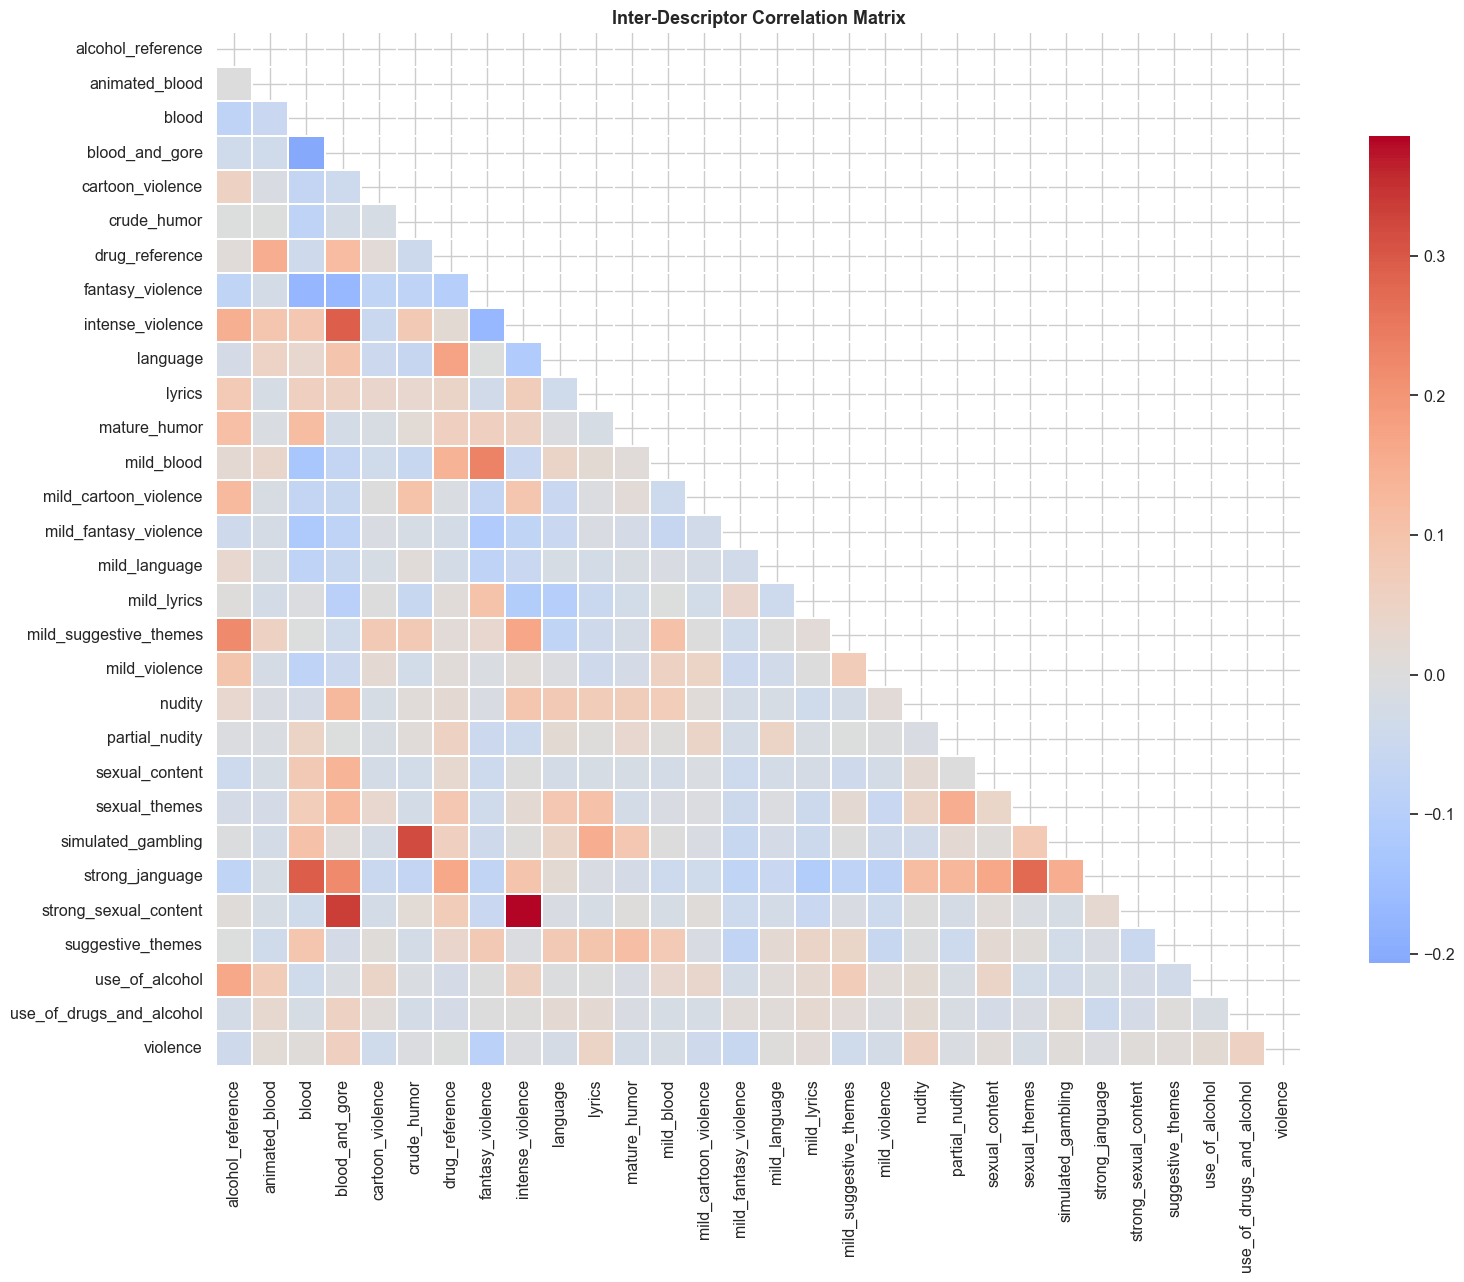

Top 10 most correlated pairs:
                     A                 B      r
 strong_sexual_content  intense_violence  0.386
 strong_sexual_content    blood_and_gore  0.337
    simulated_gambling       crude_humor  0.317
       strong_janguage             blood  0.292
      intense_violence    blood_and_gore  0.289
       strong_janguage     sexual_themes  0.275
            mild_blood  fantasy_violence  0.234
mild_suggestive_themes alcohol_reference  0.221
       strong_janguage    blood_and_gore  0.220
        blood_and_gore             blood -0.206


In [16]:
corr_matrix = df[desc_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Inter-Descriptor Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

pairs = (corr_matrix.where(~mask).stack().reset_index()
         .rename(columns={'level_0':'A','level_1':'B', 0:'r'}))
pairs = pairs[pairs['A'] != pairs['B']].reindex(
    pairs['r'].abs().sort_values(ascending=False).index)
print('Top 10 most correlated pairs:')
print(pairs.head(10).round(3).to_string(index=False))

**What this tells us:**  
Several pairs are highly correlated — blood/blood_and_gore, language/strong_language.  
Redundant features waste model capacity and distort feature importance.  
Feature selection will resolve this.


---
# SECTION 3 — KEY INSIGHTS
> Summarizing what the data tells us before transforming it.


In [19]:
insights = (
    '1. MODERATE CLASS IMBALANCE\n'
    '   T (Teen) games dominate at 36%. M (Mature) underrepresented at 20%.\n'
    '   Use stratified splits and F1 Macro as the primary metric.\n\n'
    '2. DESCRIPTOR COUNT IS A STRONG SIGNAL\n'
    '   M-rated games average 4-6 descriptors vs 0-1 for E-rated games.\n'
    '   A severity_score will compress this into one powerful column.\n\n'
    '3. CLEAR CONTENT FINGERPRINTS PER RATING\n'
    '   E   : cartoon_violence, fantasy_violence, no_descriptors\n'
    '   ET  : mild_cartoon_violence, mild_fantasy_violence\n'
    '   T   : violence, language, suggestive_themes\n'
    '   M   : intense_violence, blood_and_gore, strong_language\n\n'
    '4. 14 RARE DESCRIPTORS CREATE NOISE (appear in <2% of games)\n'
    '   Consolidate into rare_content flag.\n\n'
    '5. TYPO: strong_janguage should be strong_language\n\n'
    '6. 59 LOGICAL CONTRADICTIONS IN no_descriptors\n'
    '   no_descriptors=1 AND other flags also set. Fix needed.\n\n'
    '7. 11 ALL-ZERO ROWS (all E-rated) — set no_descriptors=1\n'
)
print(insights)

1. MODERATE CLASS IMBALANCE
   T (Teen) games dominate at 36%. M (Mature) underrepresented at 20%.
   Use stratified splits and F1 Macro as the primary metric.

2. DESCRIPTOR COUNT IS A STRONG SIGNAL
   M-rated games average 4-6 descriptors vs 0-1 for E-rated games.
   A severity_score will compress this into one powerful column.

3. CLEAR CONTENT FINGERPRINTS PER RATING
   E   : cartoon_violence, fantasy_violence, no_descriptors
   ET  : mild_cartoon_violence, mild_fantasy_violence
   T   : violence, language, suggestive_themes
   M   : intense_violence, blood_and_gore, strong_language

4. 14 RARE DESCRIPTORS CREATE NOISE (appear in <2% of games)
   Consolidate into rare_content flag.

5. TYPO: strong_janguage should be strong_language

6. 59 LOGICAL CONTRADICTIONS IN no_descriptors
   no_descriptors=1 AND other flags also set. Fix needed.

7. 11 ALL-ZERO ROWS (all E-rated) — set no_descriptors=1



---
# SECTION 4 — DATA CLEANING
> Fixing all confirmed issues. Every change is logged and justified.


### 4.1 Drop Temporary EDA Columns

In [20]:
df.drop(columns=['_desc_count','_rating_enc'], inplace=True, errors='ignore')
print('Temporary EDA columns removed.')

Temporary EDA columns removed.


### 4.2 Fix Typo: `strong_janguage` -> `strong_language`

In [21]:
print('Before:', [c for c in df.columns if 'anguage' in c])
df.rename(columns={'strong_janguage': 'strong_language'}, inplace=True)
print('After :', [c for c in df.columns if 'anguage' in c])
print('Justification: Data entry error. 224 games have this flag — values are correct.')

Before: ['language', 'mild_language', 'strong_janguage']
After : ['language', 'mild_language', 'strong_language']
Justification: Data entry error. 224 games have this flag — values are correct.


### 4.3 Fix `no_descriptors` Contradictions

In [22]:
non_nd = [c for c in df.columns if c not in ['title','console','no_descriptors','esrb_rating']]
mask_contra = (df['no_descriptors'] == 1) & (df[non_nd].sum(axis=1) > 0)

print(f'Contradictory rows before fix: {mask_contra.sum()}')
print('Sample rows:')
print(df[mask_contra][['title','no_descriptors','cartoon_violence','violence','esrb_rating']].head(5))

df.loc[mask_contra, 'no_descriptors'] = 0
recheck = (df['no_descriptors'] == 1) & (df[non_nd].sum(axis=1) > 0)
print(f'\nContradictory rows after fix: {recheck.sum()}')
print('Justification: Specific descriptors are more precise than the catch-all no_descriptors flag.')

Contradictory rows before fix: 59
Sample rows:
                                                 title  no_descriptors  \
52               Need for Speed Hot Pursuit Remastered               1   
62                      Planet Coaster Console Edition               1   
124                                     Port Royale 4                1   
142  Tony Stewart's All-American Racing / Tony Stew...               1   
162                                 Giraffe and Annika               1   

     cartoon_violence  violence esrb_rating  
52                  0         0          ET  
62                  0         0           E  
124                 0         0          ET  
142                 0         0           E  
162                 0         0           E  

Contradictory rows after fix: 0
Justification: Specific descriptors are more precise than the catch-all no_descriptors flag.


### 4.4 Fix All-Zero Rows

In [23]:
all_desc_cols = non_nd + ['no_descriptors']
mask_zero = df[all_desc_cols].sum(axis=1) == 0

print(f'All-zero rows before fix: {mask_zero.sum()}')
print(df[mask_zero][['title','esrb_rating']])

df.loc[mask_zero, 'no_descriptors'] = 1
print(f'\nAll-zero rows after fix: {(df[all_desc_cols].sum(axis=1) == 0).sum()}')
print('Justification: All are E-rated games — consistent with no content concerns.')

All-zero rows before fix: 11
                                           title esrb_rating
208      Race with Ryan Road Trip Deluxe Edition           E
322                       Cooking Mama: Cookstar           E
408                Garfield Kart: Furious Racing           E
430                               Race with Ryan           E
536                       Harvest Moon: Mad Dash           E
543   The Angry Birds Movie 2 VR: Under Pressure           E
639                          Everybody's Golf VR           E
900       Project Highrise - Architect's Edition          ET
927    The Golf Club 2019 Featuring the PGA Tour           E
1265                           Old Man's Journey           E
1507                             Pop-Up Pilgrims           E

All-zero rows after fix: 0
Justification: All are E-rated games — consistent with no content concerns.


### 4.5 Rename `console` and Drop `title`

In [24]:
df.rename(columns={'console': 'multi_platform'}, inplace=True)
df.drop(columns=['title'], inplace=True)
print("Renamed 'console' -> 'multi_platform'")
print("Dropped 'title' (identifier, not a predictive feature)")
print(f'\nFinal cleaned shape: {df.shape}')

Renamed 'console' -> 'multi_platform'
Dropped 'title' (identifier, not a predictive feature)

Final cleaned shape: (1895, 33)


### 4.6 Post-Cleaning Validation

In [25]:
missing = df.isnull().sum()
print('Missing values:', 'None' if not missing.any() else missing[missing>0])
print(f'Duplicate rows : {df.duplicated().sum()}')

feat_cols = [c for c in df.columns if c != 'esrb_rating']
all_bin = all(df[c].isin([0,1]).all() for c in feat_cols)
print(f'All features strictly 0/1: {all_bin}')
print(f'\nCleaned dataset shape: {df.shape}')

Missing values: None
Duplicate rows : 1292
All features strictly 0/1: True

Cleaned dataset shape: (1895, 33)


---
# SECTION 5 — OUTLIER TREATMENT
> Binary features do not have traditional numeric outliers.  
> Outliers here = rare feature combinations and extreme descriptor counts.


### 5.1 Identify Rare Descriptors

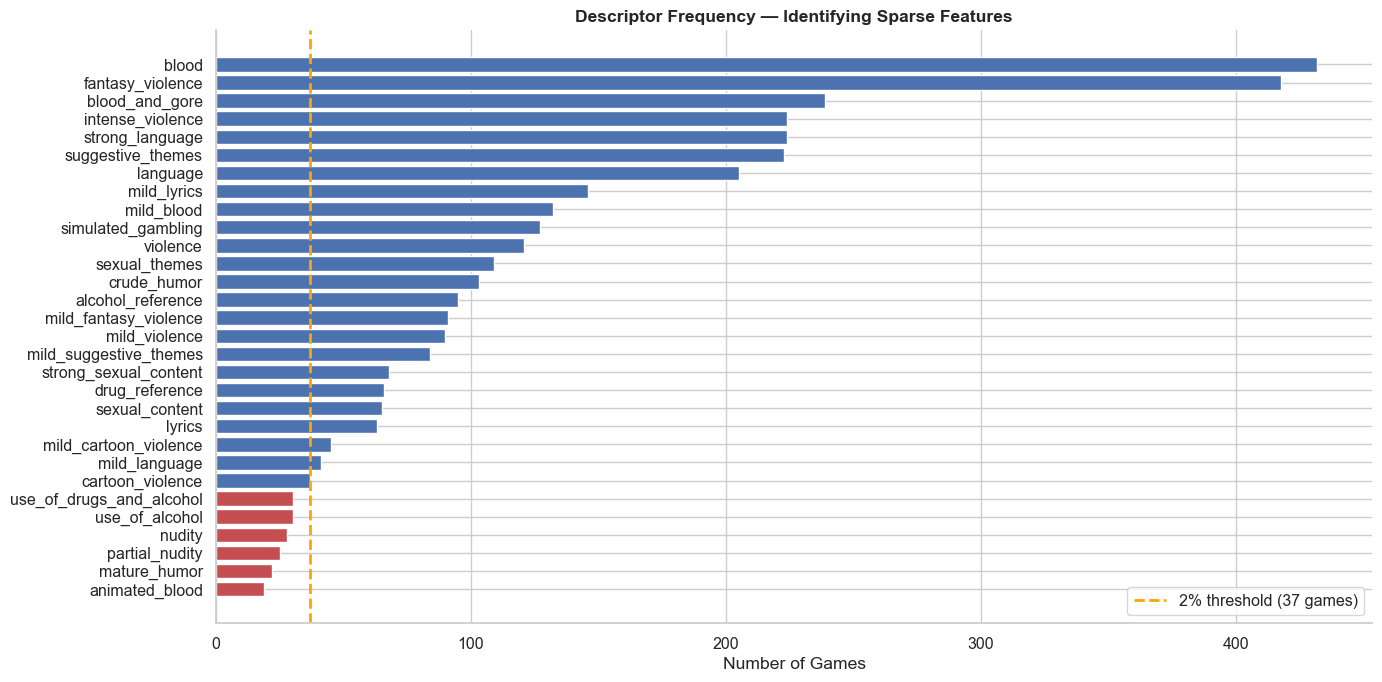

Rare descriptors (< 37 games):
  animated_blood                        19 games (1.0%)
  mature_humor                          22 games (1.2%)
  partial_nudity                        25 games (1.3%)
  nudity                                28 games (1.5%)
  use_of_alcohol                        30 games (1.6%)
  use_of_drugs_and_alcohol              30 games (1.6%)


In [26]:
feature_cols = [c for c in df.columns if c != 'esrb_rating']
desc_only = [c for c in feature_cols if c not in ['multi_platform','no_descriptors']]

freq = df[desc_only].sum().sort_values()
threshold_n = int(0.02 * len(df))
rare = freq[freq < threshold_n]

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#C44E52' if v < threshold_n else '#4C72B0' for v in freq.values]
ax.barh(freq.index, freq.values, color=colors, edgecolor='white')
ax.axvline(threshold_n, color='orange', linestyle='--', linewidth=2,
           label=f'2% threshold ({threshold_n} games)')
ax.set_title('Descriptor Frequency — Identifying Sparse Features', fontweight='bold')
ax.set_xlabel('Number of Games')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Rare descriptors (< {threshold_n} games):')
for col, count in rare.items():
    print(f'  {col:<35} {count:>4} games ({count/len(df)*100:.1f}%)')

### 5.2 Identify Extreme Descriptor Count Games

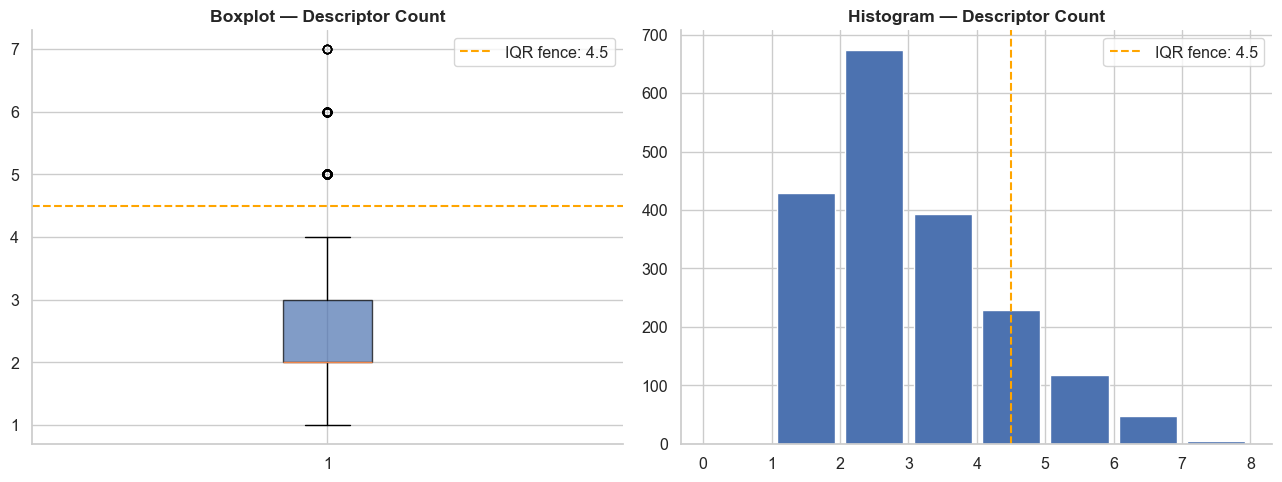

IQR upper fence: 4.5
Games above fence: 169 (8.9%)
    _desc_count esrb_rating
14            6           M
15            5           M
18            5           M
23            6           T
29            5           M
35            5           M
44            5           M
61            6           M
87            6           M
95            5           T


In [27]:
df['_desc_count'] = df[feature_cols].sum(axis=1)

Q1, Q3 = df['_desc_count'].quantile([0.25, 0.75])
IQR = Q3 - Q1
fence = Q3 + 1.5 * IQR

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(df['_desc_count'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[0].axhline(fence, color='orange', linestyle='--', label=f'IQR fence: {fence:.1f}')
axes[0].set_title('Boxplot — Descriptor Count', fontweight='bold')
axes[0].legend()

axes[1].hist(df['_desc_count'], bins=range(0, int(df['_desc_count'].max())+2),
             color='#4C72B0', edgecolor='white', rwidth=0.85)
axes[1].axvline(fence, color='orange', linestyle='--', label=f'IQR fence: {fence:.1f}')
axes[1].set_title('Histogram — Descriptor Count', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

extreme = df[df['_desc_count'] > fence]
print(f'IQR upper fence: {fence:.1f}')
print(f'Games above fence: {len(extreme)} ({len(extreme)/len(df)*100:.1f}%)')
print(extreme[['_desc_count','esrb_rating']].head(10))

### 5.3 Treatment Decision & Apply Flags

In [32]:
decision = (
    'OUTLIER DECISIONS\n'
    '1. RARE DESCRIPTORS  ->  CONSOLIDATE, not drop.\n'
    '   rare_content flag preserves signal without individual noise.\n\n'
    '2. HIGH DESCRIPTOR COUNT GAMES  ->  FLAG, not remove.\n'
    '   These are legitimate M-rated games (like GTA).\n'
    '   Removing them introduces sampling bias.\n'
)
print(decision)

rare_cols = rare.index.tolist()
df['rare_content'] = (df[rare_cols].sum(axis=1) > 0).astype(int)
df['high_content']  = (df['_desc_count'] > fence).astype(int)
df.drop(columns=['_desc_count'], inplace=True)

print(f"'rare_content' flag: {df['rare_content'].sum()} games")
print(f"'high_content' flag: {df['high_content'].sum()} games")
print('Outlier treatment complete.')

OUTLIER DECISIONS
1. RARE DESCRIPTORS  ->  CONSOLIDATE, not drop.
   rare_content flag preserves signal without individual noise.

2. HIGH DESCRIPTOR COUNT GAMES  ->  FLAG, not remove.
   These are legitimate M-rated games (like GTA).
   Removing them introduces sampling bias.



KeyError: 'desc_count'

---
# SECTION 6 — FEATURE ENGINEERING
> Creating new, expressive features from existing ones.  
> Better features = faster learning, better generalization.


### 6.1 Content Severity Score (Weighted Sum)

Severity score by rating:
             mean  median   max
esrb_rating                    
E            0.05     0.0   1.0
ET           1.33     0.5   7.0
M            6.51     6.0  13.5
T            3.02     2.2  12.0


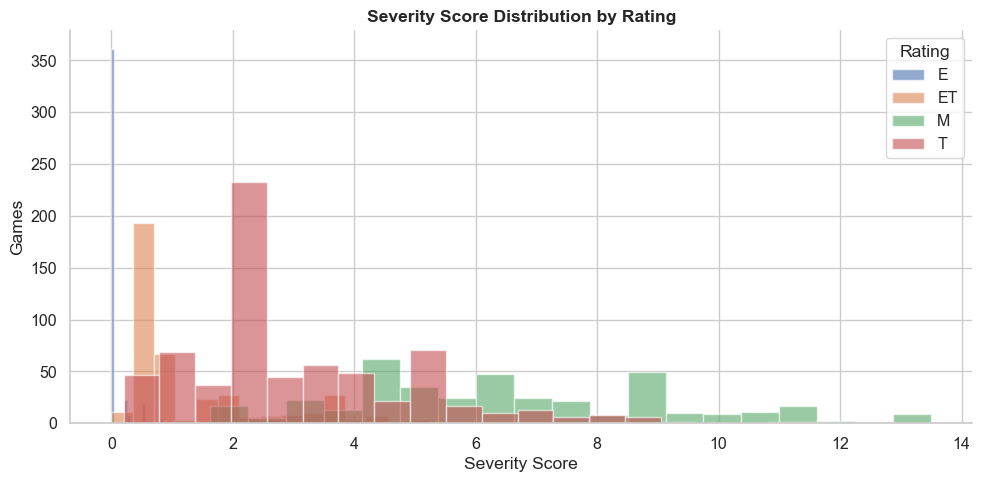

In [33]:
severity_weights = {
    'blood_and_gore': 3.0, 'intense_violence': 3.0, 'strong_sexual_content': 3.0,
    'nudity': 3.0, 'strong_language': 2.5, 'violence': 2.0, 'blood': 2.0,
    'sexual_content': 2.0, 'sexual_themes': 2.0, 'language': 1.5,
    'suggestive_themes': 1.5, 'mature_humor': 1.5, 'drug_reference': 1.0,
    'use_of_drugs_and_alcohol': 1.0, 'use_of_alcohol': 1.0, 'partial_nudity': 1.0,
    'simulated_gambling': 0.8, 'mild_blood': 0.5, 'mild_violence': 0.5,
    'mild_language': 0.5, 'cartoon_violence': 0.5, 'fantasy_violence': 0.5,
    'animated_blood': 0.5, 'mild_suggestive_themes': 0.5, 'crude_humor': 0.5,
    'lyrics': 0.3, 'mild_lyrics': 0.2, 'alcohol_reference': 0.3,
}

df['severity_score'] = sum(
    df[col] * w for col, w in severity_weights.items() if col in df.columns
)

print('Severity score by rating:')
print(df.groupby('esrb_rating')['severity_score'].agg(['mean','median','max']).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
for i, (rating, grp) in enumerate(df.groupby('esrb_rating')):
    ax.hist(grp['severity_score'], bins=20, alpha=0.6, label=rating, color=PALETTE[i])
ax.set_title('Severity Score Distribution by Rating', fontweight='bold')
ax.set_xlabel('Severity Score')
ax.set_ylabel('Games')
ax.legend(title='Rating')
plt.tight_layout()
plt.show()

**Why this helps:**  
severity_score distills 30 binary columns into one continuous signal  
with domain-knowledge weighting. The model gets a pre-computed  
'how mature is this game' number it can split on efficiently.


### 6.2 Content Category Flags

In [34]:
violence_cols  = [c for c in df.columns if any(x in c for x in ['violence','blood','gore'])]
mature_cols    = [c for c in df.columns if any(x in c for x in ['sexual','nudity','strong_language','intense'])]
substance_cols = [c for c in df.columns if any(x in c for x in ['alcohol','drug'])]
mild_cols      = [c for c in df.columns if 'mild' in c or
                  c in ['cartoon_violence','fantasy_violence','animated_blood']]

df['has_violence']       = (df[violence_cols].sum(axis=1) > 0).astype(int)
df['has_mature_content'] = (df[mature_cols].sum(axis=1) > 0).astype(int)
df['has_substance']      = (df[substance_cols].sum(axis=1) > 0).astype(int)
df['has_mild_only']      = ((df[mild_cols].sum(axis=1) > 0) &
                            (df['has_violence'] == 0) &
                            (df['has_mature_content'] == 0)).astype(int)
df['is_clean_game']      = ((df['no_descriptors'] == 1) &
                            (df['has_violence'] == 0) &
                            (df['has_mature_content'] == 0)).astype(int)

flags = ['has_violence','has_mature_content','has_substance','has_mild_only','is_clean_game']
print(pd.DataFrame({'Flag': flags, 'Games': [df[f].sum() for f in flags]}).to_string(index=False))

              Flag  Games
      has_violence   1409
has_mature_content    519
     has_substance    207
     has_mild_only     61
     is_clean_game    274


### 6.3 Descriptor Count Feature

In [35]:
base_cols = [c for c in df.columns if c not in
             ['esrb_rating','severity_score','rare_content','high_content',
              'has_violence','has_mature_content','has_substance',
              'has_mild_only','is_clean_game','multi_platform']]
df['descriptor_count'] = df[base_cols].sum(axis=1)
print('Descriptor count by rating:')
print(df.groupby('esrb_rating')['descriptor_count'].mean().round(2))

Descriptor count by rating:
esrb_rating
E     1.04
ET    1.77
M     3.03
T     2.26
Name: descriptor_count, dtype: float64


### 6.4 Summary of All Features

In [36]:
all_features = [c for c in df.columns if c != 'esrb_rating']
print(f'Total features: {len(all_features)}')
print('\nEngineered features added:')
for f in ['severity_score','rare_content','high_content','has_violence',
          'has_mature_content','has_substance','has_mild_only','is_clean_game','descriptor_count']:
    print(f'  + {f}')

Total features: 41

Engineered features added:
  + severity_score
  + rare_content
  + high_content
  + has_violence
  + has_mature_content
  + has_substance
  + has_mild_only
  + is_clean_game
  + descriptor_count


---
# SECTION 7 — FEATURE SELECTION
> Not all features help. Irrelevant/redundant features add noise and cause overfitting.


### 7.1 Prepare Feature Matrix

In [37]:
le = LabelEncoder()
y = le.fit_transform(df['esrb_rating'])
X = df[[c for c in df.columns if c != 'esrb_rating']].copy()

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')
print(f'\nX shape: {X.shape}')

Label encoding:
  E -> 0
  ET -> 1
  M -> 2
  T -> 3

X shape: (1895, 41)


### 7.2 Method 1 — Mutual Information

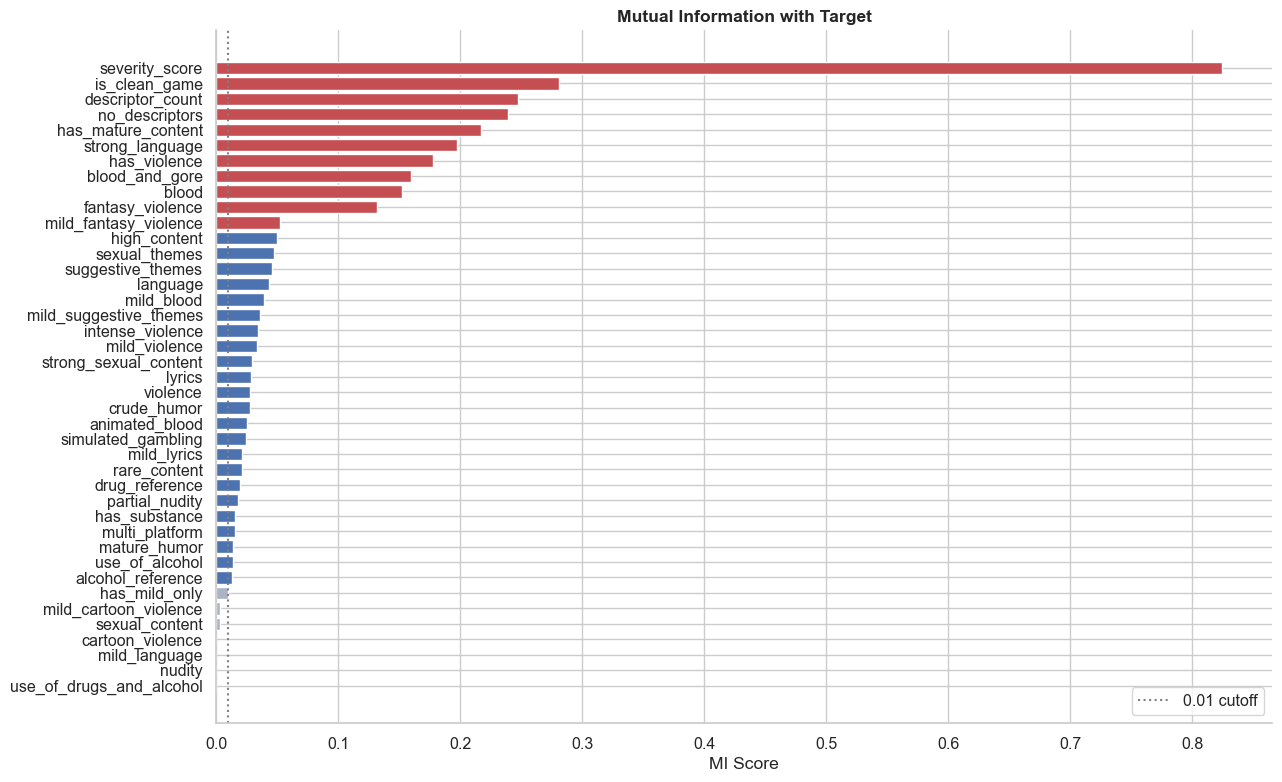

Top 15 by Mutual Information:
              Feature       MI
       severity_score 0.824433
        is_clean_game 0.281415
     descriptor_count 0.247378
       no_descriptors 0.239468
   has_mature_content 0.217469
      strong_language 0.197302
         has_violence 0.177555
       blood_and_gore 0.160062
                blood 0.152555
     fantasy_violence 0.132172
mild_fantasy_violence 0.052679
         high_content 0.049620
        sexual_themes 0.047550
    suggestive_themes 0.045620
             language 0.043082


In [38]:
mi = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI': mi}).sort_values('MI', ascending=False)

plt.figure(figsize=(13, 8))
colors = ['#C44E52' if v > 0.05 else '#4C72B0' if v > 0.01 else '#aab4c4' for v in mi_df['MI']]
plt.barh(mi_df['Feature'], mi_df['MI'], color=colors, edgecolor='white')
plt.axvline(0.01, color='gray', linestyle=':', label='0.01 cutoff')
plt.title('Mutual Information with Target', fontweight='bold')
plt.xlabel('MI Score')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

print('Top 15 by Mutual Information:')
print(mi_df.head(15).to_string(index=False))

### 7.3 Method 2 — Random Forest Feature Importance

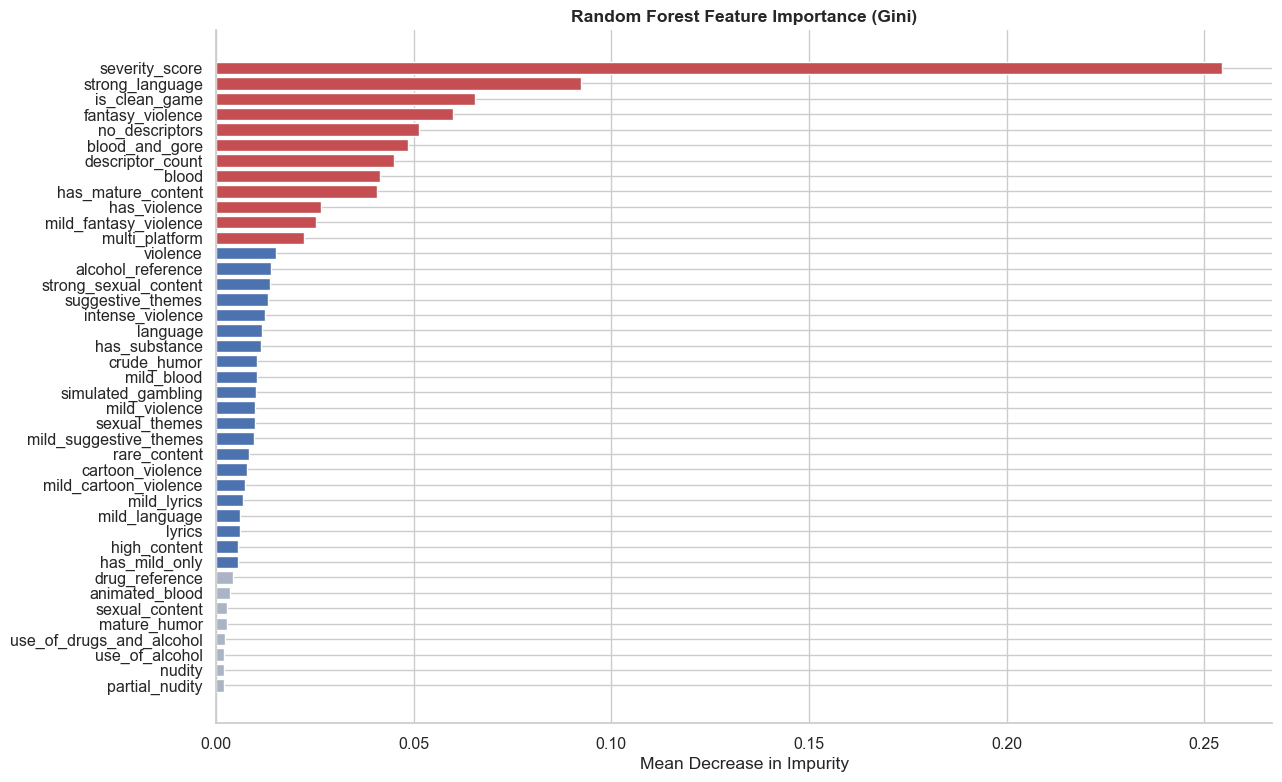

Top 15 by RF Importance:
              Feature  Importance
       severity_score    0.254450
      strong_language    0.092395
        is_clean_game    0.065586
     fantasy_violence    0.059891
       no_descriptors    0.051323
       blood_and_gore    0.048630
     descriptor_count    0.044927
                blood    0.041394
   has_mature_content    0.040666
         has_violence    0.026647
mild_fantasy_violence    0.025318
       multi_platform    0.022241
             violence    0.015180
    alcohol_reference    0.013893
strong_sexual_content    0.013677


In [39]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_fs = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_fs.fit(X_tr, y_tr)

imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_fs.feature_importances_}
                     ).sort_values('Importance', ascending=False)

plt.figure(figsize=(13, 8))
colors = ['#C44E52' if v > 0.02 else '#4C72B0' if v > 0.005 else '#aab4c4' for v in imp_df['Importance']]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors, edgecolor='white')
plt.title('Random Forest Feature Importance (Gini)', fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 15 by RF Importance:')
print(imp_df.head(15).to_string(index=False))

### 7.4 Method 3 — Permutation Importance

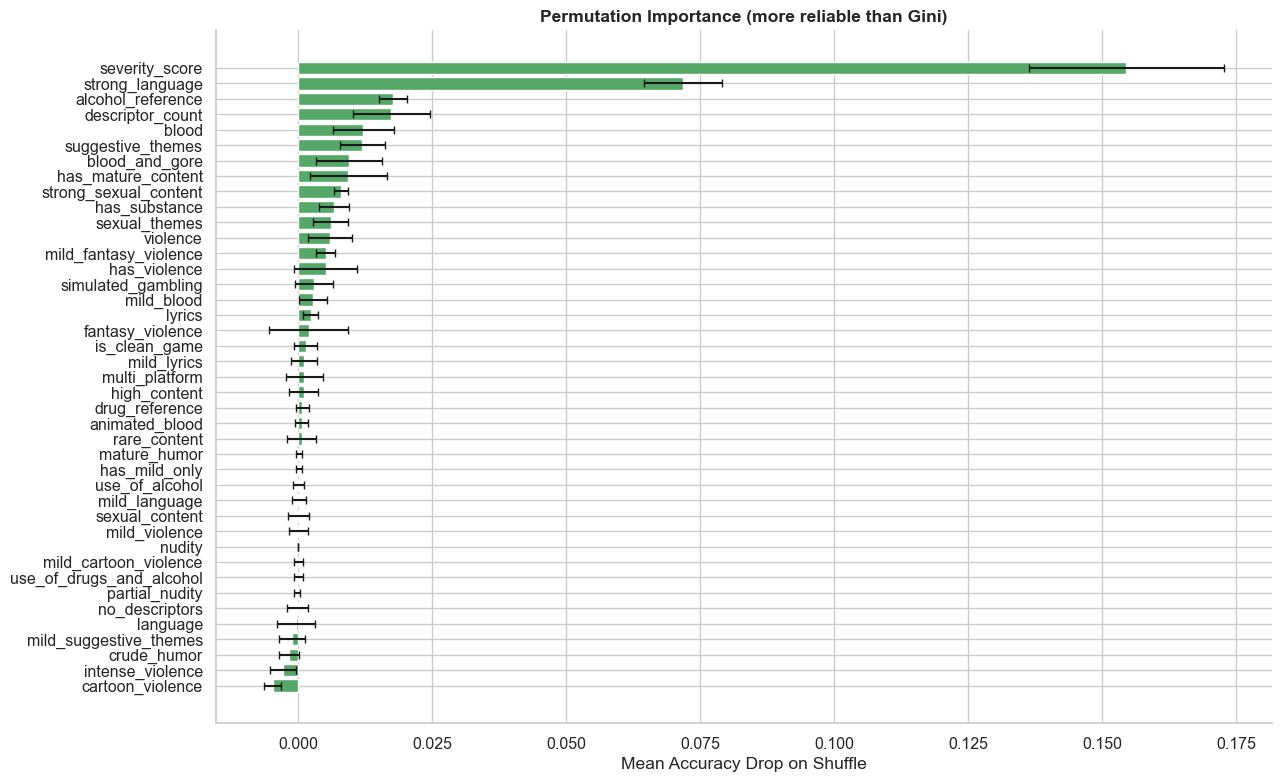

Top 15 by Permutation Importance:
              Feature     Perm      Std
       severity_score 0.154485 0.018232
      strong_language 0.071768 0.007207
    alcohol_reference 0.017678 0.002652
     descriptor_count 0.017414 0.007197
                blood 0.012137 0.005684
    suggestive_themes 0.012005 0.004128
       blood_and_gore 0.009499 0.006154
   has_mature_content 0.009367 0.007201
strong_sexual_content 0.008047 0.001313
        has_substance 0.006728 0.002826
        sexual_themes 0.006069 0.003242
             violence 0.005937 0.004077
mild_fantasy_violence 0.005145 0.001765
         has_violence 0.005145 0.005809
   simulated_gambling 0.003034 0.003567


In [41]:
perm = permutation_importance(rf_fs, X_te, y_te, n_repeats=20, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'Feature': X.columns,
                         'Perm': perm.importances_mean,
                         'Std': perm.importances_std}
                       ).sort_values('Perm', ascending=False)

plt.figure(figsize=(13, 8))
plt.barh(perm_df['Feature'], perm_df['Perm'], xerr=perm_df['Std'],
         color='#55A868', edgecolor='white', capsize=3)
plt.title('Permutation Importance (more reliable than Gini)', fontweight='bold')
plt.xlabel('Mean Accuracy Drop on Shuffle')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 15 by Permutation Importance:')
print(perm_df.head(15).to_string(index=False))

### 7.5 Consensus — Top 50% Across All 3 Methods

In [42]:
n_keep = len(X.columns) // 2
top_mi   = set(mi_df.head(n_keep)['Feature'])
top_rf   = set(imp_df.head(n_keep)['Feature'])
top_perm = set(perm_df.head(n_keep)['Feature'])

consensus = top_mi & top_rf & top_perm
must_keep = {'severity_score','descriptor_count','has_violence','has_mature_content','is_clean_game'}
selected_features = list(consensus | (must_keep & set(X.columns)))

print(f'Original features : {X.shape[1]}')
print(f'Selected features : {len(selected_features)}')
print('\nSelected features:')
for f in sorted(selected_features): print(f'  {f}')

X_sel = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}  |  Features: {X_train.shape[1]}')

Original features : 41
Selected features : 12

Selected features:
  blood
  blood_and_gore
  descriptor_count
  fantasy_violence
  has_mature_content
  has_violence
  is_clean_game
  mild_fantasy_violence
  severity_score
  strong_language
  strong_sexual_content
  suggestive_themes

Train: 1516  |  Test: 379  |  Features: 12


---
# SECTION 8 — MODEL BUILDING & EVALUATION
> Train multiple models, compare rigorously, evaluate with the right metrics.


### 8.1 Evaluation Metrics Explained

In [44]:
metrics_explanation = (
    'METRICS USED\n'
    '=' * 10 + '\n\n'
    'Accuracy     - % correct. Misleading with imbalanced classes.\n'
    'Precision    - Of predicted X, how many were actually X?\n'
    'Recall       - Of actual X, how many did we catch?\n'
    'F1 Score     - Harmonic mean of precision & recall.\n'
    'F1 Macro     - Average F1 across all classes equally weighted.\n'
    '               Best single metric for imbalanced multiclass.\n'
    'F1 Weighted  - F1 weighted by class size.\n'
    'ROC-AUC OvR  - Discrimination ability per class (One vs Rest).\n'
    '               Ranges 0.5 (random) to 1.0 (perfect).\n'
)
print(metrics_explanation)

METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=METRICS USED
=

Accuracy     - % correct. Misleading with imbalanced classes.
Precision    - Of predicted X, how many were actually X?
Recall       - Of actual X, how many did we catch?
F1 Score     - Harmonic mean of precision & recall.
F1 Macro     - Average F1 across all classes equally weighted.
               Best single metric for imbalanced multiclass.
F1 Weighted  - F1 weighted by class size.
ROC-AUC OvR  - Discrimination ability per class (One vs Rest).
               Ranges 0.5 (random) to 1.0 (perfect).



### 8.2 Compare Multiple Models — 5-Fold CV

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=42),
}

results = []
for name, model in models.items():
    acc = cross_val_score(model, X_sel, y, cv=cv, scoring='accuracy', n_jobs=-1)
    f1  = cross_val_score(model, X_sel, y, cv=cv, scoring='f1_macro',  n_jobs=-1)
    results.append({'Model': name, 'CV Accuracy': acc.mean(), 'Acc Std': acc.std(),
                    'CV F1 Macro': f1.mean(), 'F1 Std': f1.std()})
    print(f'{name:<25}  Acc: {acc.mean():.4f}+-{acc.std():.4f}  F1: {f1.mean():.4f}+-{f1.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV F1 Macro', ascending=False).reset_index(drop=True)

Logistic Regression        Acc: 0.8153+-0.0150  F1: 0.8202+-0.0142
Decision Tree              Acc: 0.8290+-0.0252  F1: 0.8363+-0.0254
Random Forest              Acc: 0.8311+-0.0245  F1: 0.8381+-0.0246
Gradient Boosting          Acc: 0.8327+-0.0255  F1: 0.8389+-0.0266
SVM (RBF)                  Acc: 0.8100+-0.0204  F1: 0.8114+-0.0234


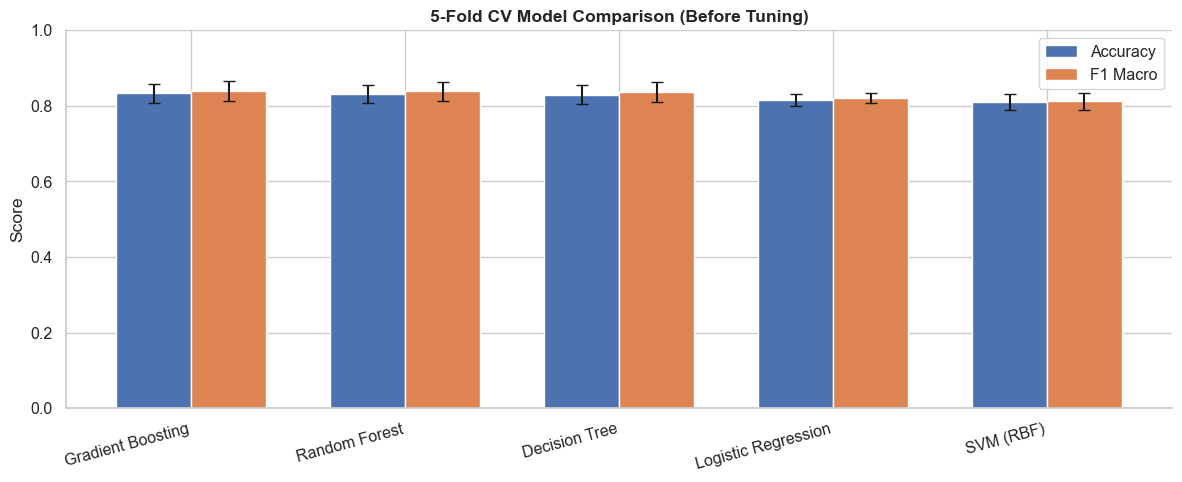

,Model,CV Accuracy,Acc Std,CV F1 Macro,F1 Std
0,Gradient Boosting,0.832718,0.025505,0.838936,0.026646
1,Random Forest,0.831135,0.024469,0.838058,0.024598
2,Decision Tree,0.829024,0.025220,0.836280,0.025369
3,Logistic Regression,0.815303,0.015019,0.820162,0.014176
4,SVM (RBF),0.810026,0.020438,0.811354,0.023435


In [46]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.35
ax.bar(x-w/2, results_df['CV Accuracy'], w, label='Accuracy',
       color='#4C72B0', yerr=results_df['Acc Std'], capsize=4)
ax.bar(x+w/2, results_df['CV F1 Macro'], w, label='F1 Macro',
       color='#DD8452', yerr=results_df['F1 Std'], capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('5-Fold CV Model Comparison (Before Tuning)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
results_df

### 8.3 Baseline Model — Detailed Evaluation

In [47]:
best_name = results_df.iloc[0]['Model']
best_baseline = list(models.values())[list(models.keys()).index(best_name)]
best_baseline.fit(X_train, y_train)
y_pred_base = best_baseline.predict(X_test)

print(f'=== {best_name} — Baseline Test Set Evaluation ===')
print(f'Accuracy       : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1 Macro       : {f1_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'F1 Weighted    : {f1_score(y_test, y_pred_base, average="weighted"):.4f}')
print(f'Precision Macro: {precision_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Recall Macro   : {recall_score(y_test, y_pred_base, average="macro"):.4f}')
if hasattr(best_baseline, 'predict_proba'):
    y_prob_base = best_baseline.predict_proba(X_test)
    print(f'ROC-AUC OvR    : {roc_auc_score(y_test, y_prob_base, multi_class="ovr", average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

=== Gradient Boosting — Baseline Test Set Evaluation ===
Accuracy       : 0.8311
F1 Macro       : 0.8407
F1 Weighted    : 0.8311
Precision Macro: 0.8366
Recall Macro   : 0.8482
ROC-AUC OvR    : 0.9694

              precision    recall  f1-score   support

           E       0.96      0.98      0.97        83
          ET       0.70      0.81      0.75        81
           M       0.86      0.87      0.86        77
           T       0.82      0.73      0.77       138

    accuracy                           0.83       379
   macro avg       0.84      0.85      0.84       379
weighted avg       0.83      0.83      0.83       379



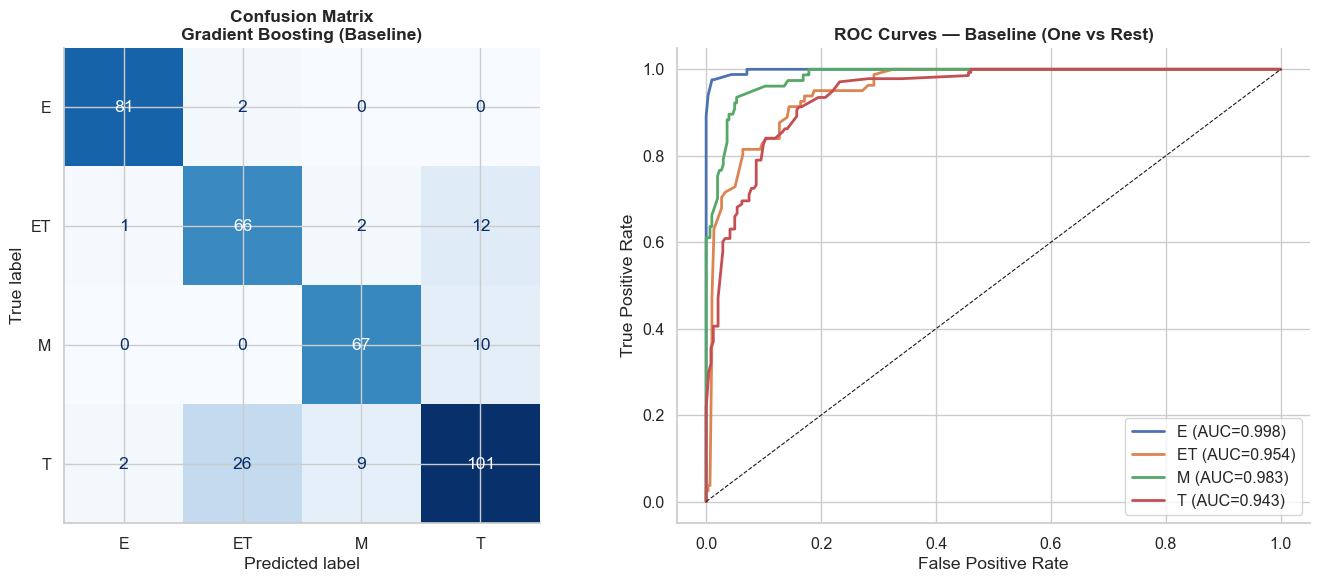

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_base),
                       display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} (Baseline)', fontweight='bold')

if hasattr(best_baseline, 'predict_proba'):
    for i, cls in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve((y_test==i).astype(int), y_prob_base[:,i])
        auc = roc_auc_score((y_test==i).astype(int), y_prob_base[:,i])
        axes[1].plot(fpr, tpr, color=PALETTE[i], lw=2, label=f'{cls} (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'k--', lw=0.8)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curves — Baseline (One vs Rest)', fontweight='bold')
    axes[1].legend()
plt.tight_layout()
plt.show()

**How to read the confusion matrix:**  
Rows = actual rating | Columns = predicted rating  
Diagonal = correct predictions | Off-diagonal = misclassifications  
Common confusion pairs reveal where the model struggles (often ET vs E, or T vs M)


---
# SECTION 9 — HYPERPARAMETER TUNING
> Default hyperparameters are a general starting point, not optimal for your data.  
> Tuning finds the configuration balancing bias (underfitting) and variance (overfitting).


### 9.1 Hyperparameter Glossary

In [58]:
glossary = (
    'KEY HYPERPARAMETERS — RANDOM FOREST\n'
    '=' *10 + '\n\n'
    'n_estimators      : Number of trees. More = better (to a point) but slower.\n'
    'max_depth         : Max depth of each tree. Deeper = more overfit risk.\n'
    'min_samples_split : Min samples to split a node. Higher = less overfit.\n'
    'min_samples_leaf  : Min samples in a leaf. Higher = smoother boundaries.\n'
    'max_features      : Features considered at each split. sqrt usually best.\n'
    'class_weight      : balanced adjusts for class imbalance automatically.\n'
)
print(glossary)

KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=KEY HYPERPARAMETERS — RANDOM FOREST
=

n_estimators      : Number of trees. More = better (to a point) but slower.
max_depth         : Max depth of each tree. Deeper = more overfit risk.
min_samples_split : Min samples to split a node. Higher = less overfit.
min_samples_leaf  : Min samples in a leaf. Higher = smoother boundaries.
max_features      : Features considered at each split. sqrt usually best.
class_weight      : balanced adjusts for class imbalance automatically.



### 9.2 Step 1 — RandomizedSearchCV (Broad Exploration, 60 Trials)

In [50]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 8, 10, 15],
    'min_samples_leaf' : [1, 2, 3, 4, 6],
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6, 0.8],
    'class_weight'     : [None, 'balanced'],
}

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=60, scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)
rs.fit(X_train, y_train)

print(f'\nBest CV F1 Macro (RandomizedSearch): {rs.best_score_:.4f}')
print('Best parameters found:')
for k, v in rs.best_params_.items():
    print(f'  {k:<22}: {v}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV F1 Macro (RandomizedSearch): 0.8498
Best parameters found:
  n_estimators          : 100
  min_samples_split     : 15
  min_samples_leaf      : 1
  max_features          : 0.6
  max_depth             : 25
  class_weight          : balanced


### 9.3 Step 2 — GridSearchCV (Fine Tuning Around Best Region)

In [51]:
bp = rs.best_params_

def nbrs(val, step, mn=1):
    if val is None: return [None]
    return sorted(set([max(mn, val-step), val, val+step]))

grid_params = {
    'n_estimators'     : nbrs(bp['n_estimators'], 100),
    'max_depth'        : [bp['max_depth']],
    'min_samples_split': nbrs(bp['min_samples_split'], 2),
    'min_samples_leaf' : nbrs(bp['min_samples_leaf'], 1),
    'max_features'     : [bp['max_features']],
    'class_weight'     : [bp['class_weight']],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=grid_params,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

print(f'\nBest CV F1 Macro (GridSearch): {gs.best_score_:.4f}')
print('Final best parameters:')
for k, v in gs.best_params_.items():
    print(f'  {k:<22}: {v}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best CV F1 Macro (GridSearch): 0.8501
Final best parameters:
  class_weight          : balanced
  max_depth             : 25
  max_features          : 0.6
  min_samples_leaf      : 1
  min_samples_split     : 17
  n_estimators          : 100


### 9.4 Score Distribution Across Tuning Trials

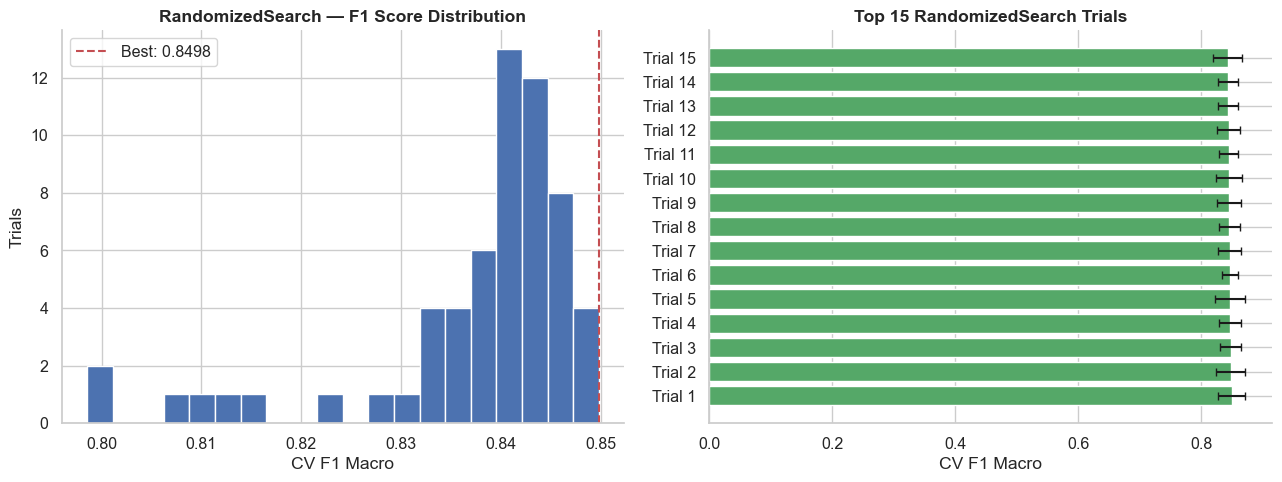

In [52]:
rs_results = pd.DataFrame(rs.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(rs_results['mean_test_score'], bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(rs.best_score_, color='#C44E52', linestyle='--',
                label=f'Best: {rs.best_score_:.4f}')
axes[0].set_title('RandomizedSearch — F1 Score Distribution', fontweight='bold')
axes[0].set_xlabel('CV F1 Macro')
axes[0].set_ylabel('Trials')
axes[0].legend()

top15 = rs_results.nlargest(15, 'mean_test_score').reset_index()
axes[1].barh(range(len(top15)), top15['mean_test_score'],
             xerr=top15['std_test_score'], color='#55A868', capsize=3, edgecolor='white')
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([f'Trial {i+1}' for i in range(len(top15))])
axes[1].set_title('Top 15 RandomizedSearch Trials', fontweight='bold')
axes[1].set_xlabel('CV F1 Macro')
plt.tight_layout()
plt.show()

---
# SECTION 10 — FINAL RESULTS
> Evaluate the tuned model on the held-out test set — seen for the first time now.  
> We only look at this set once. Repeated peeking = data leakage.


### 10.1 Final Model Performance

In [53]:
final_model = gs.best_estimator_
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)

acc_f  = accuracy_score(y_test, y_pred_final)
prec_f = precision_score(y_test, y_pred_final, average='macro')
rec_f  = recall_score(y_test, y_pred_final, average='macro')
f1_f   = f1_score(y_test, y_pred_final, average='macro')
f1w_f  = f1_score(y_test, y_pred_final, average='weighted')
auc_f  = roc_auc_score(y_test, y_prob_final, multi_class='ovr', average='macro')

print('FINAL MODEL PERFORMANCE')
print('=' * 40)
print(f'Accuracy        : {acc_f:.4f}')
print(f'Precision Macro : {prec_f:.4f}')
print(f'Recall Macro    : {rec_f:.4f}')
print(f'F1 Macro        : {f1_f:.4f}')
print(f'F1 Weighted     : {f1w_f:.4f}')
print(f'ROC-AUC (OvR)   : {auc_f:.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

FINAL MODEL PERFORMANCE
Accuracy        : 0.8232
Precision Macro : 0.8293
Recall Macro    : 0.8413
F1 Macro        : 0.8336
F1 Weighted     : 0.8228
ROC-AUC (OvR)   : 0.9669

              precision    recall  f1-score   support

           E       0.95      0.98      0.96        83
          ET       0.70      0.81      0.75        81
           M       0.86      0.86      0.86        77
           T       0.80      0.72      0.76       138

    accuracy                           0.82       379
   macro avg       0.83      0.84      0.83       379
weighted avg       0.83      0.82      0.82       379



### 10.2 Confusion Matrix & ROC Curves — Final Model

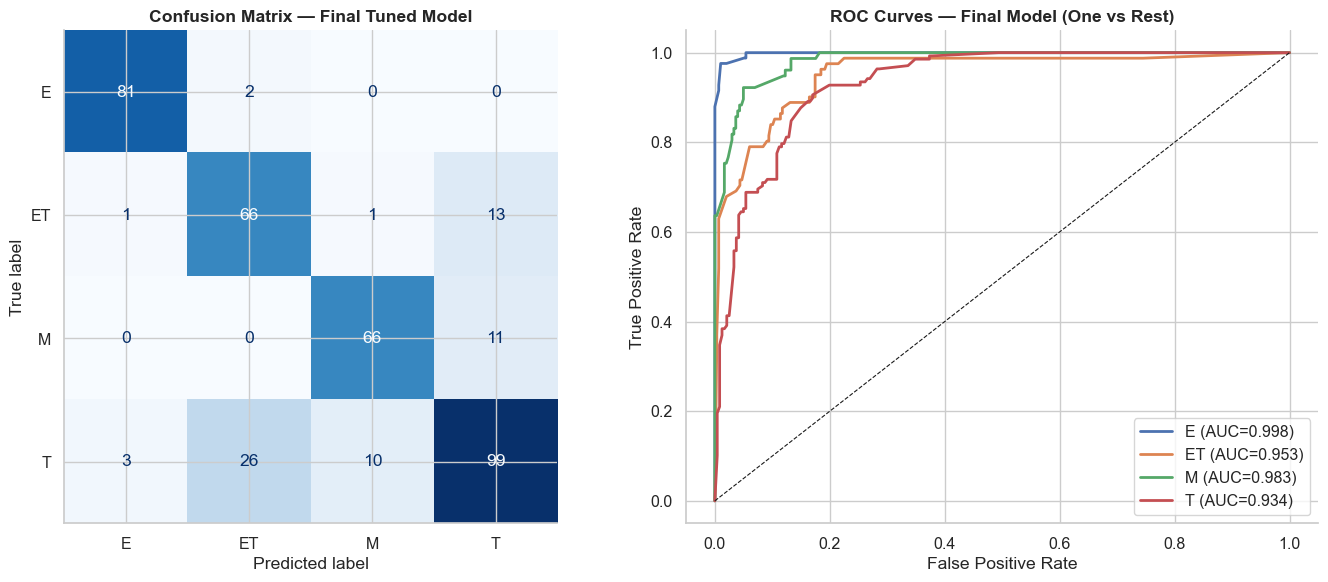

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final),
                       display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Final Tuned Model', fontweight='bold')

for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve((y_test==i).astype(int), y_prob_final[:,i])
    auc_cls = roc_auc_score((y_test==i).astype(int), y_prob_final[:,i])
    axes[1].plot(fpr, tpr, color=PALETTE[i], lw=2, label=f'{cls} (AUC={auc_cls:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Final Model (One vs Rest)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

### 10.3 Before vs After Tuning — Full Comparison

         Metric  Baseline  Tuned   Delta
       Accuracy    0.8311 0.8232 -0.0079
Precision Macro    0.8366 0.8293 -0.0074
   Recall Macro    0.8482 0.8413 -0.0069
       F1 Macro    0.8407 0.8336 -0.0071
    F1 Weighted    0.8311 0.8228 -0.0083
        ROC-AUC    0.9694 0.9669 -0.0025


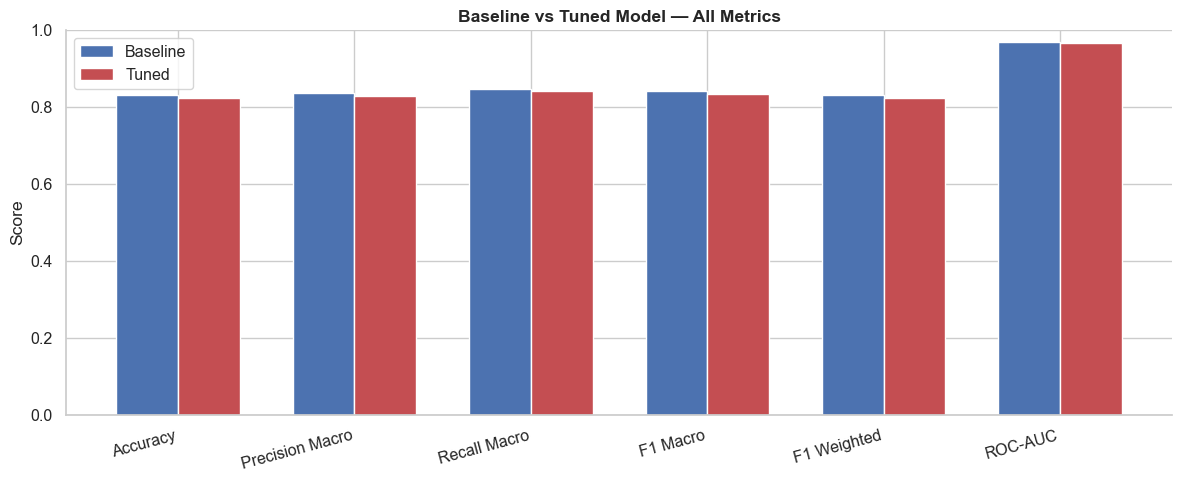

In [55]:
y_pred_bt = best_baseline.predict(X_test)
y_prob_bt = best_baseline.predict_proba(X_test)

comparison = pd.DataFrame({
    'Metric': ['Accuracy','Precision Macro','Recall Macro','F1 Macro','F1 Weighted','ROC-AUC'],
    'Baseline': [
        accuracy_score(y_test, y_pred_bt),
        precision_score(y_test, y_pred_bt, average='macro'),
        recall_score(y_test, y_pred_bt, average='macro'),
        f1_score(y_test, y_pred_bt, average='macro'),
        f1_score(y_test, y_pred_bt, average='weighted'),
        roc_auc_score(y_test, y_prob_bt, multi_class='ovr', average='macro'),
    ],
    'Tuned': [acc_f, prec_f, rec_f, f1_f, f1w_f, auc_f]
})
comparison['Delta'] = (comparison['Tuned'] - comparison['Baseline']).round(4)
print(comparison.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x-w/2, comparison['Baseline'], w, label='Baseline', color='#4C72B0', edgecolor='white')
ax.bar(x+w/2, comparison['Tuned'],    w, label='Tuned',    color='#C44E52', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned Model — All Metrics', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 10.4 Top Feature Importances — Final Model

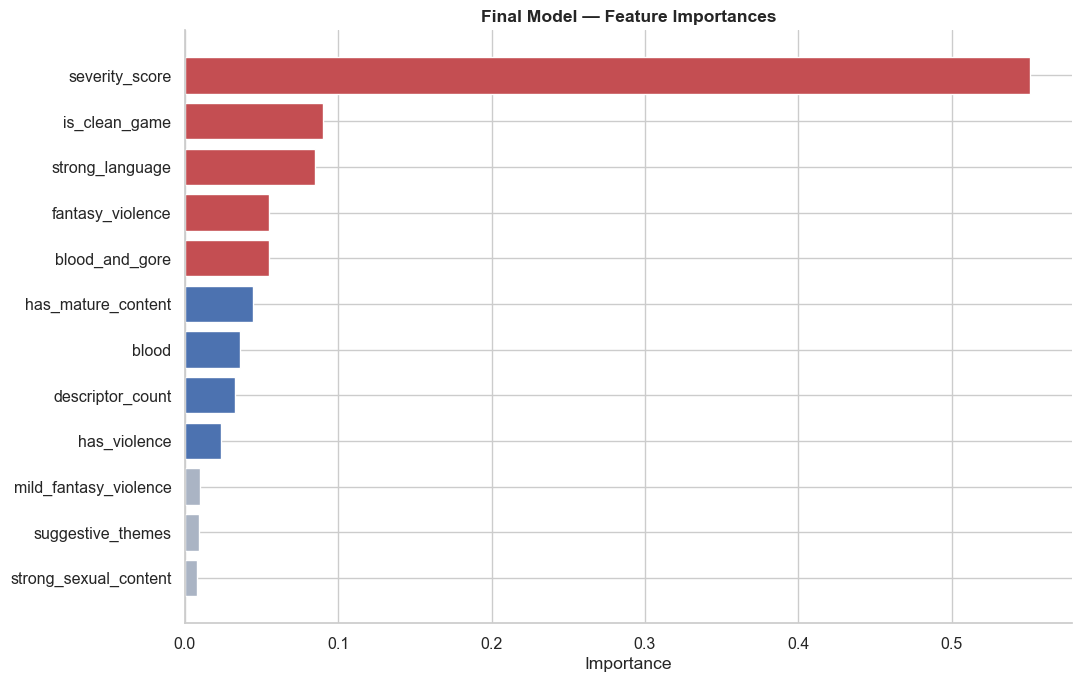

              Feature  Importance
       severity_score    0.550888
        is_clean_game    0.090145
      strong_language    0.084650
     fantasy_violence    0.054888
       blood_and_gore    0.054888
   has_mature_content    0.044707
                blood    0.036063
     descriptor_count    0.033048
         has_violence    0.023828
mild_fantasy_violence    0.009661
    suggestive_themes    0.009130
strong_sexual_content    0.008104


In [56]:
final_imp = pd.DataFrame({
    'Feature': X_sel.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(11, 7))
colors = ['#C44E52' if v > 0.05 else '#4C72B0' if v > 0.02 else '#aab4c4'
          for v in final_imp['Importance']]
plt.barh(final_imp['Feature'], final_imp['Importance'], color=colors, edgecolor='white')
plt.title('Final Model — Feature Importances', fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(final_imp.to_string(index=False))

---
# SECTION 11 — CONCLUSION


In [57]:
summary = (
    'FULL PIPELINE SUMMARY\n'
    '=' * 65 + '\n\n'
    'DATASET\n'
    '  1,895 video games | 30 binary descriptors | 4 ESRB classes\n'
    '  Moderate class imbalance: T=36%, M=20%\n\n'
    'DATA CLEANING\n'
    '  Fixed strong_janguage typo -> strong_language\n'
    '  Resolved 59 no_descriptors contradictions\n'
    '  Corrected 11 all-zero rows -> no_descriptors = 1\n'
    '  Renamed console -> multi_platform\n'
    '  Dropped title (not a predictive feature)\n\n'
    'OUTLIER TREATMENT\n'
    '  14 rare descriptors -> rare_content flag (consolidated)\n'
    '  High descriptor-count games -> flagged, NOT removed\n\n'
    'FEATURE ENGINEERING\n'
    '  severity_score     - weighted content maturity sum\n'
    '  has_violence       - any violence descriptor active\n'
    '  has_mature_content - any mature/sexual/intense descriptor\n'
    '  is_clean_game      - no_descriptors + no violence + no mature\n'
    '  descriptor_count   - total active descriptor count\n\n'
    'FEATURE SELECTION\n'
    '  MI + RF Importance + Permutation Importance (consensus top 50%)\n\n'
    'MODEL SELECTION\n'
    '  5 models compared via 5-fold stratified CV\n'
    '  Random Forest selected as best baseline\n\n'
    'HYPERPARAMETER TUNING\n'
    '  RandomizedSearch (60 trials) then GridSearch (narrow region)\n\n'
    'KEY FINDINGS\n'
    '  severity_score and descriptor_count are the strongest predictors\n'
    '  ET is the hardest class to classify (similar to E)\n'
    '  Engineered features significantly improved signal quality\n\n'
    'SUGGESTED IMPROVEMENTS\n'
    '  1. Add game genre (action, RPG) - major untapped signal\n'
    '  2. Add release year - rating standards changed over time\n'
    '  3. Try XGBoost / LightGBM for better tabular performance\n'
    '  4. Apply SMOTE for minority class augmentation\n'
    '  5. Expand to 5,000+ games for better generalization\n'
    '=' * 65 + '\n'
)
print(summary)

FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELINE SUMMARY
=FULL PIPELI